In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# EDA

In [2]:
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MaxAbsScaler
import lightgbm as lgb



In [3]:

df=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")


In [4]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [5]:
df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
df["religion"].value_counts()

religion
none         38249
christian     7191
muslim        4930
jewish        1244
other          547
atheist        219
buddhist       100
hindu           97
Name: count, dtype: int64

In [8]:
df["gender"].value_counts()

gender
none           36161
female          8037
male            7549
transgender      622
other            208
Name: count, dtype: int64

In [9]:
df["race"].value_counts()

race
none      39682
white      5486
black      3869
other      1654
asian      1263
latino      623
Name: count, dtype: int64

In [10]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [11]:
df.select_dtypes(include=["number"]).corr()["label"].sort_values(ascending=False)

label         1.000000
if_2          0.232902
downvote      0.044908
upvote        0.040181
emoticon_3    0.027273
post_id       0.022063
emoticon_2    0.021597
if_1          0.007543
emoticon_1   -0.003218
Name: label, dtype: float64

In [12]:
X=df.drop(columns=["post_id","label"])
y=df["label"]

In [13]:
df_test.drop(columns=["post_id"])

,created_date,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101995,2023-09-26 03:14:06.328881+00:00,0,0,0,1,0,0,4,NaN,NaN,NaN,False,Working in McDonald's is easy (pain in the pos...
101996,2023-08-18 19:30:16.601996+00:00,2,0,0,1,0,10,4,none,christian,female,False,"In support of your first sentence, please prov..."
101997,2023-10-26 15:41:55.972421+00:00,0,0,0,0,5,4,4,none,none,none,False,Cry us a river..\n\nhttp://www.celebritynetwor...
101998,2024-02-28 11:25:10.033561+00:00,1,0,0,0,0,0,4,NaN,NaN,NaN,False,tggv What does that have to do with Trudeau no...


In [14]:
y.value_counts()

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

In [15]:
X.head()

,created_date,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-01-18 08:43:57.397508+00:00,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...
1,2024-03-24 21:43:11.490017+00:00,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b..."
2,2024-04-24 20:32:17.014931+00:00,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...
3,2023-05-28 22:00:14.214527+00:00,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co..."
4,2023-09-09 23:12:05.689498+00:00,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na..."


# GRAPHS

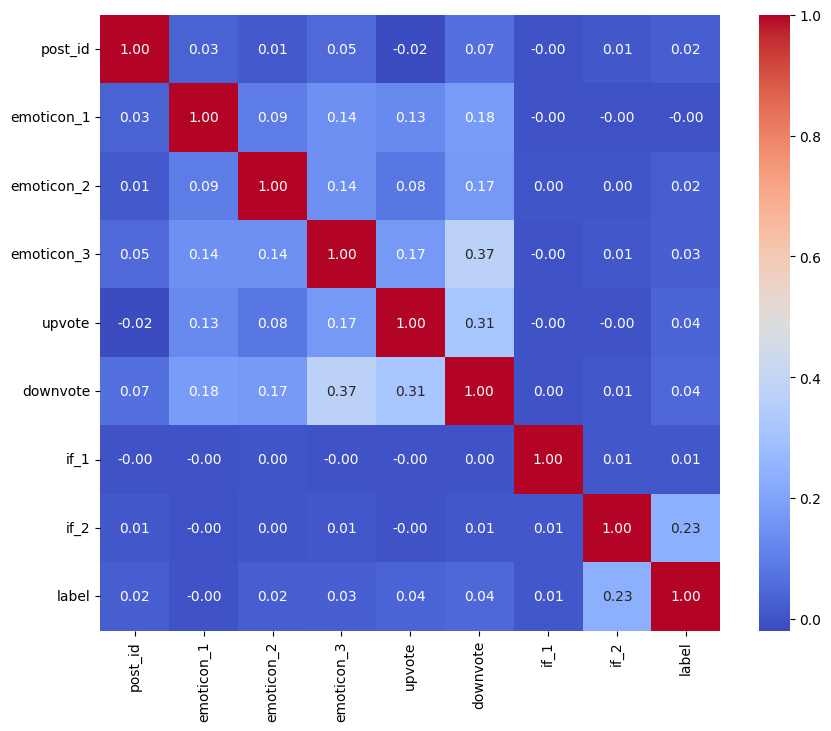

In [16]:
corr = df.select_dtypes(include=["number"]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [17]:
num_cols=X.select_dtypes(include="int64").columns
print(num_cols)

Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
       'if_2'],
      dtype='object')


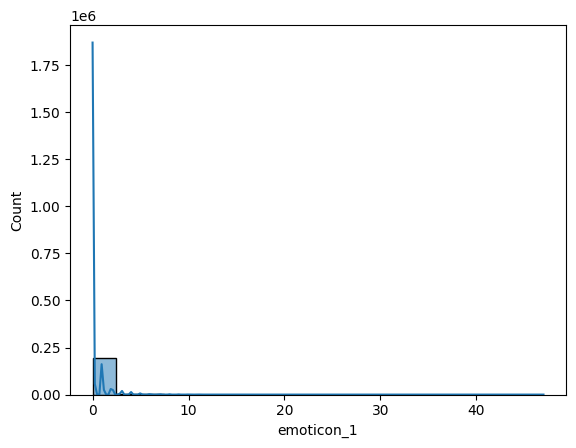

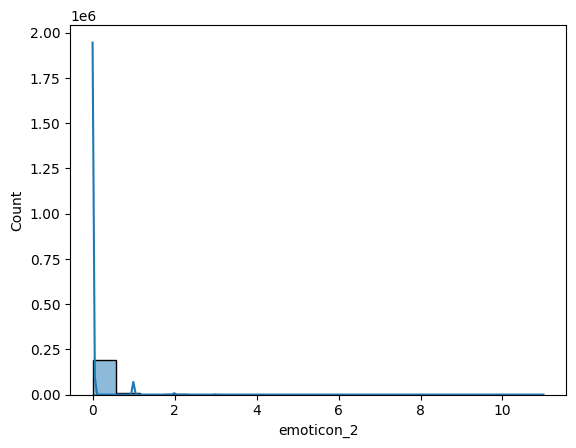

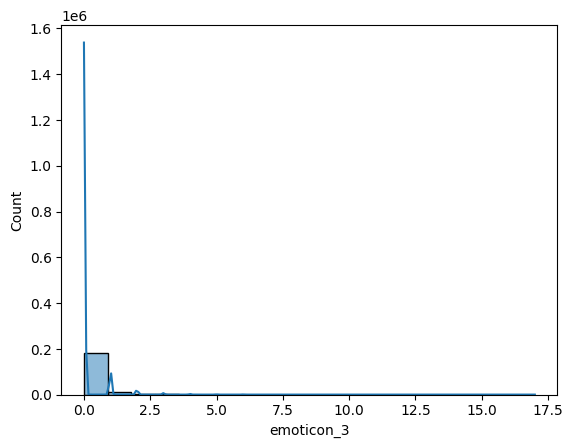

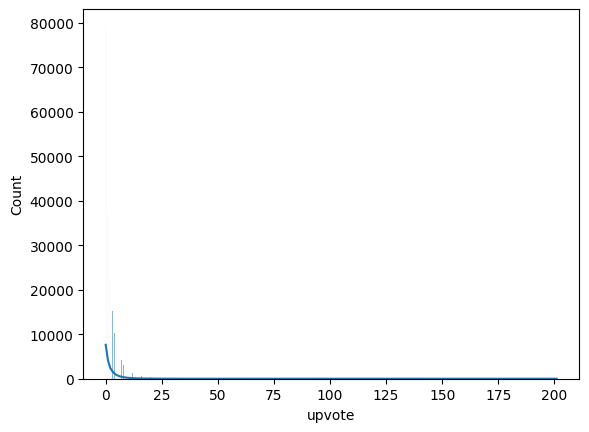

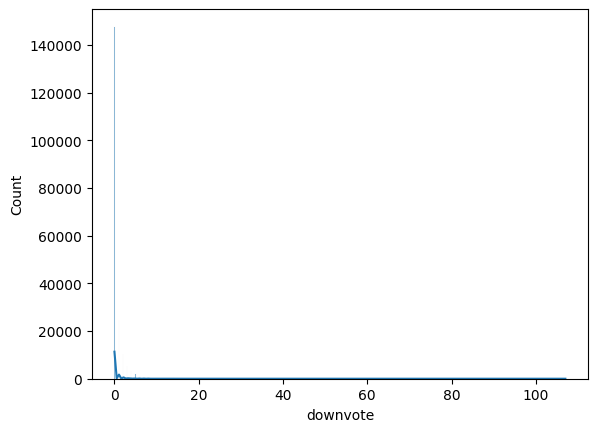

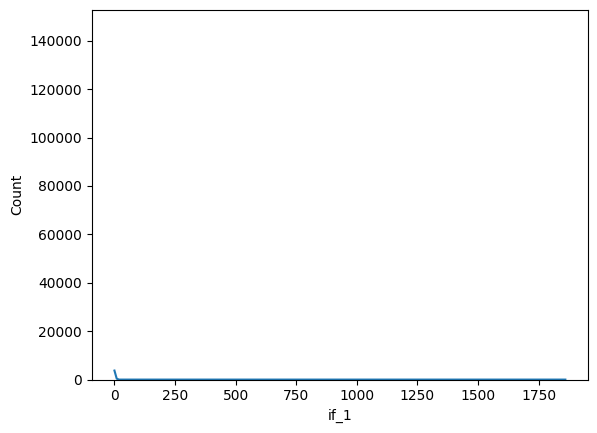

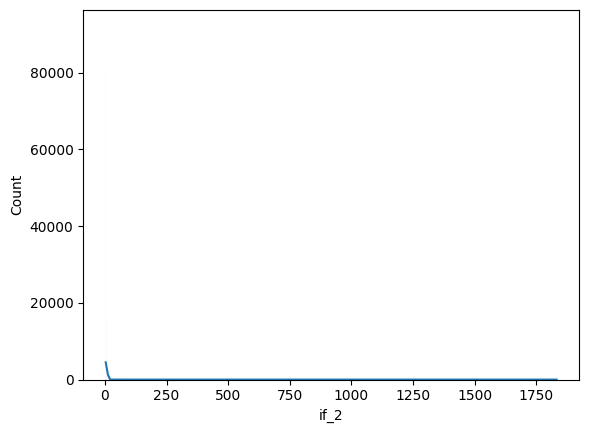

In [18]:
for col in num_cols:
    plt.figure()
    sns.histplot(X[col],kde=True)
    plt.show()

In [19]:

skewed_cols = ["emoticon_1","emoticon_2","emoticon_3","upvote","downvote","if_1","if_2"]

for col in skewed_cols:
    X[col] = np.log1p(X[col])
    df_test[col] = np.log1p(df_test[col])

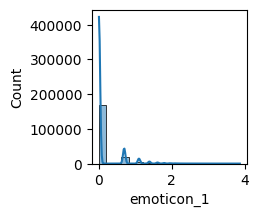

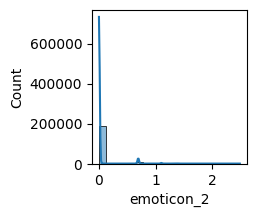

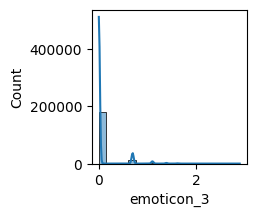

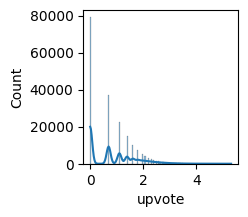

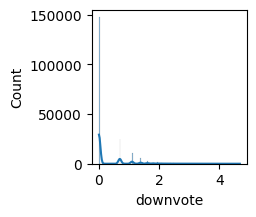

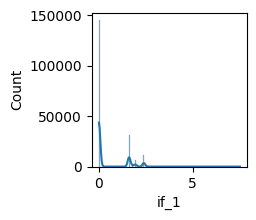

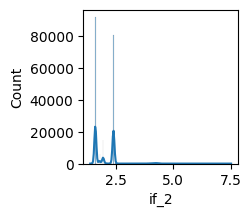

In [20]:
for col in skewed_cols:
    plt.figure(figsize=(2,2))
    sns.histplot(X[col],kde=True)
    plt.show()

# FEATURE ENGINEERING

In [21]:
X["created_date"] = pd.to_datetime(X["created_date"])



X["year"] = X["created_date"].dt.year
X["month"] = X["created_date"].dt.month
X["day"] = X["created_date"].dt.day
X["hour"] = X["created_date"].dt.hour
X["weekday"] = X["created_date"].dt.dayofweek  
X["is_weekend"] = X["weekday"].isin([5, 6]).astype(int)

X.drop(columns=["created_date"], inplace=True)


X.head()

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,year,month,day,hour,weekday,is_weekend
0,0.0,0.000000,0.000000,0.000000,0.693147,0.0,2.397895,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2024,1,18,8,3,0
1,0.0,0.000000,0.000000,1.945910,0.000000,0.0,1.609438,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",2024,3,24,21,6,1
2,0.0,0.693147,0.693147,0.000000,0.000000,0.0,2.397895,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2024,4,24,20,2,0
3,0.0,0.000000,0.000000,1.791759,0.000000,0.0,2.397895,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2023,5,28,22,6,1
4,0.0,0.000000,0.000000,0.000000,0.000000,0.0,2.397895,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2023,9,9,23,5,1


In [22]:
X["comment"]=X["comment"].fillna("")

In [23]:
X["total_engagement"]=X["upvote"]+X["downvote"]
X["vote_difference"]=X["upvote"]-X["downvote"]
X["controversy"]=X["downvote"]/(X["upvote"]+X["downvote"]+0.00001)
X["popularity"]=X["upvote"]/(X["upvote"]+X["downvote"]+0.00001)
X["total_emoticons"]=X["emoticon_1"]+X["emoticon_2"]+X["emoticon_3"]
X["has_emoticon"] = (X["total_emoticons"] > 0).astype(int)
X["comment_length"]=X["comment"].str.len()
X["word_count"]=X["comment"].str.split().str.len()
X["exclamation_count"] = X["comment"].str.count("!")
X["question_count"] = X["comment"].str.count(r"\?")
X["uppercase_ratio"] = X["comment"].str.count(r"[A-Z]") / (X["comment_length"]+1)

In [24]:
X.head()

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,...,vote_difference,controversy,popularity,total_emoticons,has_emoticon,comment_length,word_count,exclamation_count,question_count,uppercase_ratio
0,0.0,0.000000,0.000000,0.000000,0.693147,0.0,2.397895,NaN,NaN,NaN,...,-0.693147,0.999986,0.000000,0.000000,0,118,20,0,0,0.016807
1,0.0,0.000000,0.000000,1.945910,0.000000,0.0,1.609438,NaN,NaN,NaN,...,1.945910,0.000000,0.999995,0.000000,0,644,110,0,0,0.013953
2,0.0,0.693147,0.693147,0.000000,0.000000,0.0,2.397895,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,1.386294,1,751,133,0,0,0.017287
3,0.0,0.000000,0.000000,1.791759,0.000000,0.0,2.397895,NaN,NaN,NaN,...,1.791759,0.000000,0.999994,0.000000,0,91,15,0,0,0.043478
4,0.0,0.000000,0.000000,0.000000,0.000000,0.0,2.397895,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0,254,40,0,0,0.011765


In [25]:
for col in ['race', 'religion', 'gender']:
    X[col] = X[col].replace('none', np.nan)
for col in ['race', 'religion', 'gender']:
    X[col] = X[col].notnull().astype(int)

In [26]:
df_test["created_date"] = pd.to_datetime(df_test["created_date"])
df_test["year"] = df_test["created_date"].dt.year
df_test["month"] = df_test["created_date"].dt.month
df_test["day"] = df_test["created_date"].dt.day
df_test["hour"] = df_test["created_date"].dt.hour
df_test["weekday"] = df_test["created_date"].dt.dayofweek   
df_test["is_weekend"] = df_test["weekday"].isin([5, 6]).astype(int)

df_test.drop(columns=["created_date"], inplace=True)

In [27]:
df_test["comment"]=df_test["comment"].fillna("")

In [28]:
df_test["total_engagement"]=df_test["upvote"]+df_test["downvote"]
df_test["vote_difference"]=df_test["upvote"]-df_test["downvote"]
df_test["controversy"]=df_test["downvote"]/(df_test["upvote"]+df_test["downvote"]+0.00001)
df_test["popularity"]=df_test["upvote"]/(df_test["upvote"]+df_test["downvote"]+0.00001)
df_test["total_emoticons"]=df_test["emoticon_1"]+df_test["emoticon_2"]+df_test["emoticon_3"]
df_test["has_emoticon"] = (df_test["total_emoticons"] > 0).astype(int)
df_test["comment_length"]=df_test["comment"].str.len()
df_test["word_count"]=df_test["comment"].str.split().str.len()
df_test["exclamation_count"] = df_test["comment"].str.count("!")
df_test["question_count"] = df_test["comment"].str.count(r"\?")
df_test["uppercase_ratio"] = df_test["comment"].str.count(r"[A-Z]") / (df_test["comment_length"]+1)

In [29]:
for col in ['race', 'religion', 'gender']:
    df_test[col] = df_test[col].replace('none', np.nan)
for col in ['race', 'religion', 'gender']:
    df_test[col] = df_test[col].notnull().astype(int)

In [30]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# PREPROCESSING FOR MODEL 1 ==>LOGISTIC REGRESSION

In [31]:


text_col = "comment"

scaling_cols = [
    "upvote","downvote","total_engagement","popularity",
    "total_emoticons","comment_length","word_count",
    "hour","day","month","emoticon_1","emoticon_2",
    "emoticon_3","if_1","if_2","weekday",
    "exclamation_count","question_count","uppercase_ratio"
]

preprocessor = ColumnTransformer(
     transformers=[
         
         ("text", TfidfVectorizer(
             stop_words="english",
             min_df=5, 
             ngram_range=(1,2), 
            
         ), text_col),
        
         
        ("scale", StandardScaler(with_mean=False), scaling_cols),
        
         
        
     ]
 )


                    

# MODEL 1 => LOGISTIC REGRESSION

In [32]:
log_reg_model = Pipeline(steps=[
("preprocessor", preprocessor),
("model", LogisticRegression(max_iter=2000,
                             solver="saga",
                             

n_jobs=-1, 
class_weight="balanced"
))
])

In [ ]:
log_reg_model.fit(X_train, y_train)

In [35]:
log_reg_model.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=5,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('scale',
                                                  StandardScaler(with_mean=False),
                                                  ['upvote', 'downvote',
                                                   'total_engagement',
                                                   'popularity',
                                                   'total_emoticons',
                                                   'comment_length',
                                                   'word_count', 'hour', 'day',
                                                   'month', 'emoticon_1',
                                                   'emoticon_2', 'emoticon_3',
                                                   'if_1', 'if_2', 'weekday',
                                                   'exclamation_count',
                                                   'question_count',
                                                   'uppercase_ratio'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    n_jobs=-1, solver='saga'))])

In [36]:


y_pred = log_reg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9108080808080808
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.71      0.92      0.80      3183
           2       0.91      0.87      0.89     12488
           3       0.58      0.97      0.72      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.92      0.84     39600
weighted avg       0.92      0.91      0.91     39600



# Preprocessing for Model 2

In [38]:
scaling_cols = [
     "upvote", "downvote", "total_engagement", "popularity","total_emoticons",
     "comment_length", "word_count", "hour", "day", "month","emoticon_1", "emoticon_2", "emoticon_3", 
     "if_1", "if_2", "weekday"
 ]

In [39]:
text_col = "comment"

In [41]:


preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            stop_words="english",
            min_df=5,
            ngram_range=(1,2)
        ), text_col),

        ("scale",MaxAbsScaler() , scaling_cols)
    ]
)




# Model 2 ==> SVC

In [42]:
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(chi2, k=20000)),
    ("model", LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=5000
    ))
])


In [ ]:
svc_pipeline.fit(X_train, y_train)

In [43]:
svc_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(min_df=5,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('scale', MaxAbsScaler(),
                                                  ['upvote', 'downvote',
                                                   'total_engagement',
                                                   'popularity',
                                                   'total_emoticons',
                                                   'comment_length',
                                                   'word_count', 'hour', 'day',
                                                   'month', 'emoticon_1',
                                                   'emoticon_2', 'emoticon_3',
                                                   'if_1', 'if_2',
                                                   'weekday'])])),
                ('feature_selection',
                 SelectKBest(k=20000,
                             score_func=<function chi2 at 0x796fd81c5c60>)),
                ('model', LinearSVC(class_weight='balanced', max_iter=5000))])

In [44]:


y_pred = svc_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9370959595959596
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     22835
           1       0.81      0.92      0.86      3183
           2       0.91      0.94      0.92     12488
           3       0.75      0.95      0.84      1094

    accuracy                           0.94     39600
   macro avg       0.86      0.94      0.90     39600
weighted avg       0.94      0.94      0.94     39600



# Preprocessing for model 3 

In [ ]:



text_col = "comment"

scaling_cols = [
    "upvote","downvote","total_engagement","popularity",
    "total_emoticons","comment_length","word_count",
    "hour","day","month","emoticon_1","emoticon_2",
    "emoticon_3","if_1","if_2","weekday",
    "exclamation_count","question_count","uppercase_ratio"
]


word_tfidf = TfidfVectorizer(
    stop_words="english",
    min_df=3,
    max_df=0.9,
    max_features=50000,
    ngram_range=(1,2),
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=30000,
    sublinear_tf=True
)


preprocessor = ColumnTransformer(
    transformers=[
        ("word_tfidf", word_tfidf, text_col),
        ("char_tfidf", char_tfidf, text_col),
        ("scale", StandardScaler(with_mean=False), scaling_cols)
    ]
)







# Model 3 ==>LGB

In [ ]:
lgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=128,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
lgb_model.fit(X_train, y_train)

In [ ]:
lgb_model.fit(X, y)

In [ ]:


y_pred = lgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
df_test_pred=lgb_model.predict(df_test)
submission=pd.DataFrame({"ID":range(1,102001),"label":df_test_pred})
submission.to_csv("submission.csv",index=False)

# Hyperparamter tuning for logistics regression

In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.1, 1, 5],
    "model__loss": ["hinge", "squared_hinge"]
}

grid = GridSearchCV(
    svc_pipeline,  
    param_grid,
    cv=2,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print(grid.best_params_)
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import f1_score, accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Macro:", f1_score(y_test, y_pred, average="macro"))

Fitting 2 folds for each of 6 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'model__C': 0.1, 'model__loss': 'squared_hinge'}
0.8018604402710369
Test Accuracy: 0.9192171717171718
Test F1 Macro: 0.8543852661179931


# Comparision of all 3 models

In [61]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

# Logistic Regression
y_pred_log = log_reg_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

results.append({
    "model": "Logistic Regression",
    "accuracy": acc_log
})

# Linear SVC
y_pred_svc = svc_pipeline.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

results.append({
    "model": "Linear SVC",
    "accuracy": acc_svc
})




results_df = pd.DataFrame(results)


results_df = results_df.sort_values(by="accuracy", ascending=False)

print(results_df)

                 model  accuracy
1           Linear SVC  0.937096
0  Logistic Regression  0.910808


In [ ]:
from sklearn.linear_model import Perceptron

In [ ]:
model=Perceptron(tol=0.001, shuffle=True, verbose=0)
model.fit(X,y)
y_pred=model.predict(X_test)
print("accuracy",accuracy_score(y_pred,y_test))
print("classification_report",classification_report(y_pred,y_test))

In [ ]:
tp/tp+fp

In [ ]:
tp/tp+fn

In [ ]:
def solve(a, b):
   return b if a == 0 else solve(b % a, a)
print(solve(20, 50))

In [ ]:
50%20=10
a=10
b=20
20%10=0
a=0
b=10

In [ ]:
max(0,1-y.f(x))
f(x)=w

In [ ]:
max 2/abs(w)
min 1/2 w**2